# Proyek Analisis Data: [Air Quality Dataset]
- **Nama:** [Henokh William Christianos Lase]
- **Email:** [cdcc325d6y2751@student.devacademy.id]
- **ID Dicoding:** [henokhwcl]

## Menentukan Pertanyaan Bisnis

(*Dongsi dipilih untuk mewakili kepadatan pusat kota, sementara Dingling sebagai pembanding wilayah latar belakang (background station*)).

1. Bagaimana perbandingan rata-rata konsentrasi polutan `PM2.5` antara wilayah **Dongsi** (area urban) dan **Dingling** (area pinggiran) selama periode tahun 2013 hingga 2017? Dan apakah faktor musim berpengaruh?

2. Bagaimana perbedaan tren rata-rata bulanan konsentrasi `PM2.5` pada wilayah **Dongsi** dan **Dingling** dalam rentang waktu Januari 2013 hingga Februari 2017?

## Import Semua Packages/Library yang Digunakan

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
import warnings
import glob
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style="whitegrid")

## Data Wrangling

### Gathering Data
- **Dongsi** mewakili karakteristik wilayah pusat kota dengan aktivitas padat
- **Dingling** mewakili wilayah pinggiran kota yang berfungsi sebagai area kontrol dalam analisis ini
- Data dimuat dari folder `sample_data` dan digabungkan menjadi satu DataFrame untuk mempermudah proses komparasi

In [4]:
directory = "sample_data"

all_files = glob.glob(os.path.join(directory, "*.csv"))

all_df_list = []

for file in all_files:
    df = pd.read_csv(file)
    all_df_list.append(df)

main_df = pd.concat(all_df_list, ignore_index=True)

print(f"Berhasil memuat {len(all_files)} file.")
print(f"Total baris data: {main_df.shape[0]}")
print(f"Wilayah yang terdeteksi: {main_df['station'].unique()}")
main_df.head()

Berhasil memuat 2 file.
Total baris data: 70128
Wilayah yang terdeteksi: ['Dongsi' 'Dingling']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


**Insight:**
- Proses penggabungan menghasilkan total **70.128 baris** data (**35.064 baris dari masing-masing wilayah**)
- Kedua dataset memiliki 18 kolom yang identik, mencakup parameter waktu, polutan udara, dan kondisi meteorologi, sehingga proses integrasi berjalan konsisten
- Data kini telah siap untuk diuji guna melihat perbedaan kualitas udara antara area urban (**Dongsi**) dan area rural/suburban (**Dingling**)


### Assessing Data
- Memastikan kolom waktu dan sensor memiliki tipe data yang tepat
- Melihat sebaran data kosong pada parameter polutan dan cuaca di kedua wilayah
- Memastikan tidak ada baris data yang berulang
- Meninjau nilai minimum, maksimum, dan rata-rata untuk mendeteksi adanya anomali awal

In [5]:
print("--- Informasi Dasar Data ---")
main_df.info()

print("\n--- Jumlah Missing Values ---")
print(main_df.isna().sum())

print("\n--- Jumlah Duplikasi Data ---")
print(f"Total duplikat: {main_df.duplicated().sum()}")

print("\n--- Ringkasan Statistik ---")
display(main_df.describe())

print("\n--- Daftar Wilayah ---")
print(main_df['station'].unique())

--- Informasi Dasar Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70128 entries, 0 to 70127
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       70128 non-null  int64  
 1   year     70128 non-null  int64  
 2   month    70128 non-null  int64  
 3   day      70128 non-null  int64  
 4   hour     70128 non-null  int64  
 5   PM2.5    68599 non-null  float64
 6   PM10     68919 non-null  float64
 7   SO2      68735 non-null  float64
 8   NO2      67293 non-null  float64
 9   CO       64919 non-null  float64
 10  O3       68250 non-null  float64
 11  TEMP     70055 non-null  float64
 12  PRES     70058 non-null  float64
 13  DEWP     70055 non-null  float64
 14  RAIN     70057 non-null  float64
 15  wd       69910 non-null  object 
 16  WSPM     70071 non-null  float64
 17  station  70128 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 9.6+ MB

--- Jumlah Missing Values ---
No      

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,70128.000000,70128.000000,70128.000000,70128.000000,70128.000000,68599.000000,68919.000000,68735.000000,67293.000000,64919.000000,68250.000000,70055.000000,70058.000000,70055.000000,70057.000000,70071.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,76.096168,97.058107,15.143683,40.571245,1113.602150,62.833821,13.678797,1010.154873,1.976737,0.062194,1.857312
std,10122.177085,1.177205,3.448728,8.800155,6.922236,80.382746,90.367184,19.859209,33.074029,1075.751643,56.242766,11.411903,10.521693,13.824324,0.769776,1.295161
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.800000,982.400000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,17.000000,31.000000,3.000000,15.000000,400.000000,20.000000,3.300000,1001.600000,-9.600000,0.000000,1.000000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,50.000000,72.000000,7.000000,32.000000,800.000000,54.000000,14.600000,1009.800000,2.400000,0.000000,1.500000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,107.000000,135.000000,19.000000,59.000000,1400.000000,87.000000,23.400000,1018.500000,14.600000,0.000000,2.300000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,881.000000,955.000000,300.000000,258.000000,10000.000000,1071.000000,41.400000,1042.000000,28.800000,52.100000,10.500000



--- Daftar Wilayah ---
['Dongsi' 'Dingling']


**Insight:**
- Berdasarkan pengecekan menggunakan main_df.isna().sum(), ditemukan sejumlah nilai yang hilang pada kolom polutan utama (seperti `PM2.5`, `SO2`, `CO`) dan parameter meteorologi di kedua wilayah. Hal ini memerlukan penanganan pada tahap pembersihan
- Kolom waktu masih terpisah dalam format integer, sehingga perlu digabungkan menjadi format datetime untuk analisis kronologis
- Tidak ditemukan data duplikat dalam dataset ini. Ringkasan statistik awal menunjukkan adanya perbedaan rentang nilai `PM2.5` yang cukup lebar antara **Dongsi** dan **Dingling**

### Cleaning Data
- Menghapus kolom indeks bawaan yang tidak diperlukan dalam analisis
- Mengisi nilai yang hilang pada parameter polutan (`PM2.5`, `SO2`, dll.) dan meteorologi menggunakan metode interpolasi linear untuk menjaga kontinuitas data deret waktu
- Mengisi nilai kosong pada kolom arah angin (`wd`) dengan metode *forward fill*
- Menggabungkan kolom tahun, bulan, hari, dan jam menjadi satu kolom bertipe `datetime` agar mempermudah pemrosesan data berbasis waktu

In [6]:
main_df.drop("No", axis=1, inplace=True)

numeric_cols = main_df.select_dtypes(include=['float64', 'int64']).columns
main_df[numeric_cols] = main_df[numeric_cols].interpolate(method='linear')

main_df['wd'].fillna(method='ffill', inplace=True)

main_df['datetime'] = pd.to_datetime(main_df[['year', 'month', 'day', 'hour']])

print("Informasi data setelah pembersihan:")
main_df.info()
print("\nJumlah missing values yang tersisa:")
print(main_df.isna().sum())

Informasi data setelah pembersihan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70128 entries, 0 to 70127
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   year      70128 non-null  int64         
 1   month     70128 non-null  int64         
 2   day       70128 non-null  int64         
 3   hour      70128 non-null  int64         
 4   PM2.5     70128 non-null  float64       
 5   PM10      70128 non-null  float64       
 6   SO2       70128 non-null  float64       
 7   NO2       70128 non-null  float64       
 8   CO        70128 non-null  float64       
 9   O3        70128 non-null  float64       
 10  TEMP      70128 non-null  float64       
 11  PRES      70128 non-null  float64       
 12  DEWP      70128 non-null  float64       
 13  RAIN      70128 non-null  float64       
 14  wd        70128 non-null  object        
 15  WSPM      70128 non-null  float64       
 16  station   70128 non-nu

**Insight:**
- Masalah data kosong yang diidentifikasi pada tahap Assessing telah ditangani menggunakan teknik interpolasi linear. Metode ini dipilih untuk menjaga kontinuitas data deret waktu agar tidak terjadi kekosongan saat proses visualisasi tren
- Setelah proses pembersihan, dataset kini memiliki nol (0) missing value dan kolom `datetime` yang terstandarisasi, sehingga data siap untuk dianalisis lebih lanjut


## Exploratory Data Analysis (EDA)

### Explore ...
- Membandingkan nilai rata-rata polutan antara wilayah urban (**Dongsi**) dan wilayah kontrol (**Dingling**)
- Melihat hubungan antara faktor meteorologi (**seperti suhu dan angin**) terhadap konsentrasi polusi di masing-masing wilayah
- Mengamati penyebaran data polutan untuk mengidentifikasi

In [7]:
print("Rata-rata polutan berdasarkan wilayah:")
comparison_df = main_df.groupby('station')[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean().reset_index()
display(comparison_df)

print("\nKorelasi di Wilayah Dongsi:")
display(main_df[main_df['station'] == 'Dongsi'][['PM2.5', 'TEMP', 'PRES', 'DEWP', 'WSPM']].corr())

print("\nKorelasi di Wilayah Dingling:")
display(main_df[main_df['station'] == 'Dingling'][['PM2.5', 'TEMP', 'PRES', 'DEWP', 'WSPM']].corr())

Rata-rata polutan berdasarkan wilayah:


,station,PM2.5,PM10,SO2,NO2,CO,O3
0,Dingling,66.845557,84.113713,11.797849,27.306013,925.111838,70.530792
1,Dongsi,86.144243,110.347617,18.506142,53.953078,1331.913045,57.700357



Korelasi di Wilayah Dongsi:


,PM2.5,TEMP,PRES,DEWP,WSPM
PM2.5,1.000000,-0.138325,-0.005307,0.128231,-0.301284
TEMP,-0.138325,1.000000,-0.837532,0.819164,0.048800
PRES,-0.005307,-0.837532,1.000000,-0.770367,0.038617
DEWP,0.128231,0.819164,-0.770367,1.000000,-0.278875
WSPM,-0.301284,0.048800,0.038617,-0.278875,1.000000



Korelasi di Wilayah Dingling:


,PM2.5,TEMP,PRES,DEWP,WSPM
PM2.5,1.000000,-0.088894,-0.005834,0.135109,-0.254722
TEMP,-0.088894,1.000000,-0.837857,0.823871,-0.003754
PRES,-0.005834,-0.837857,1.000000,-0.765785,0.087316
DEWP,0.135109,0.823871,-0.765785,1.000000,-0.314360
WSPM,-0.254722,-0.003754,0.087316,-0.314360,1.000000


**Insight:**
- Berdasarkan rata-rata polutan, wilayah **Dongsi** secara konsisten memiliki nilai `PM2.5`, `NO2`, dan `CO` yang lebih tinggi dibandingkan **Dingling**. Hal ini mengonfirmasi perbedaan beban polusi antara pusat kota dan pinggiran
- Di kedua wilayah, terdapat korelasi negatif antara kecepatan angin (`WSPM`) dengan `PM2.5`, yang menunjukkan bahwa angin yang lebih kencang cenderung membantu membersihkan polutan dari udara
- Meskipun level polusinya berbeda, pola hubungan antar variabel cuaca di kedua wilayah cenderung serupa, menunjukkan bahwa faktor meteorologi memiliki pengaruh yang universal terhadap kualitas udara di Beijing

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbedaan pola fluktuasi `PM2.5` bulanan antara wilayah pusat kota (**Dongsi**) dan wilayah pinggiran (**Dingling**) sepanjang tahun?


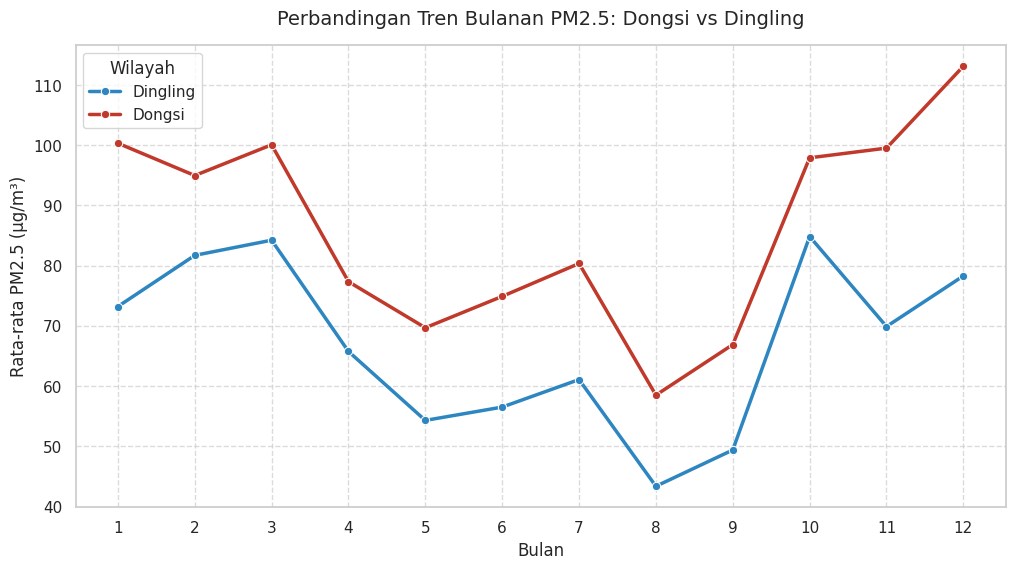

In [8]:
monthly_trend = main_df.groupby(['station', 'month'])['PM2.5'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_trend,
    x='month',
    y='PM2.5',
    hue='station',
    marker='o',
    linewidth=2.5,
    palette={'Dongsi': '#C0392B', 'Dingling': '#2E86C1'}
)

plt.title('Perbandingan Tren Bulanan PM2.5: Dongsi vs Dingling', fontsize=14, pad=15)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Rata-rata PM2.5 (µg/m³)', fontsize=12)
plt.xticks(range(1, 13))
plt.legend(title='Wilayah')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

- Wilayah **Dongsi** secara konsisten memiliki kadar `PM2.5` yang lebih tinggi daripada **Dingling** sepanjang tahun
- Kedua wilayah mengalami lonjakan polusi pada periode yang sama (**Januari-Februari & November-Desember**), menunjukkan pengaruh faktor eksternal (**musim dingin**) yang merata
- Selisih polusi antara pusat kota dan pinggiran tetap terjaga meski pola fluktuasinya serupa


### Pertanyaan 2: Apakah kecepatan angin `WSPM` memiliki pengaruh yang sama besarnya dalam menurunkan tingkat polusi di kedua wilayah tersebut?

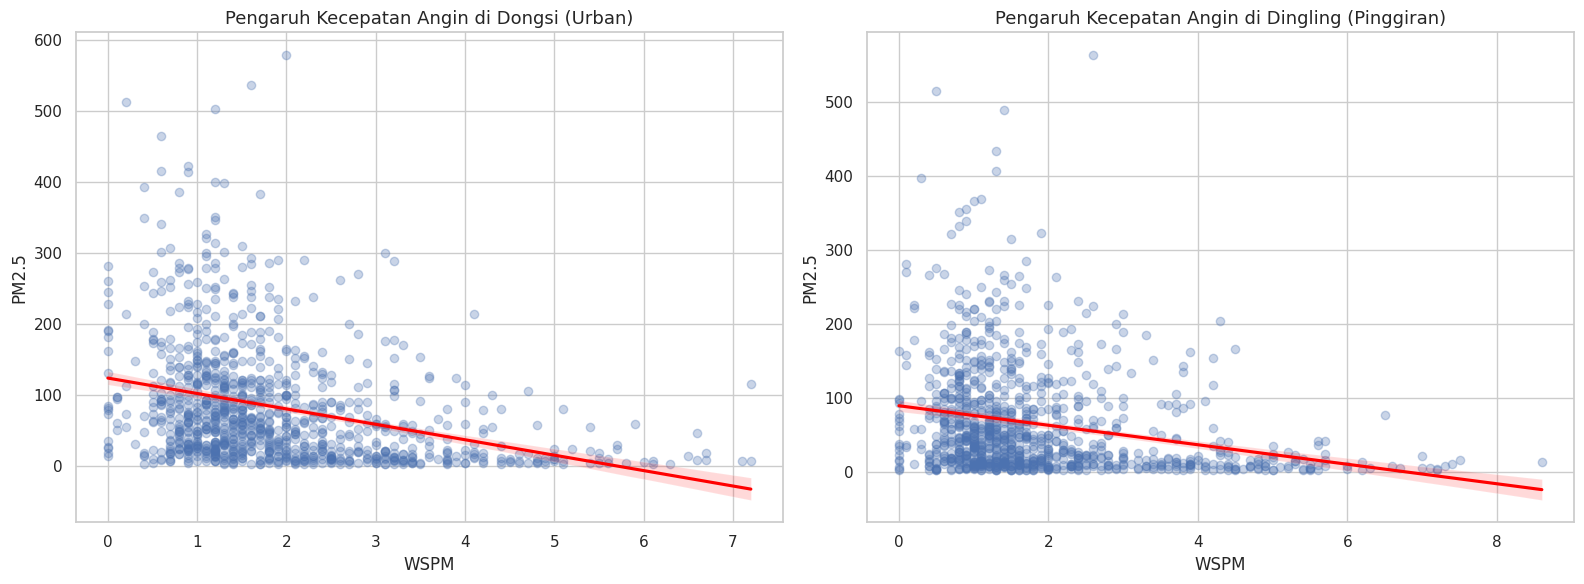

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.regplot(x='WSPM', y='PM2.5', data=main_df[main_df['station']=='Dongsi'].sample(1000),
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=ax[0])
ax[0].set_title('Pengaruh Kecepatan Angin di Dongsi (Urban)', fontsize=13)

sns.regplot(x='WSPM', y='PM2.5', data=main_df[main_df['station']=='Dingling'].sample(1000),
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=ax[1])
ax[1].set_title('Pengaruh Kecepatan Angin di Dingling (Pinggiran)', fontsize=13)

plt.tight_layout()
plt.show()

**Insight:**
- Terjadi korelasi negatif yang kuat di kedua wilayah; semakin tinggi kecepatan angin, semakin rendah konsentrasi `PM2.5`
- Wilayah **Dongsi** membutuhkan kecepatan angin yang lebih tinggi untuk mencapai level kebersihan yang sama dengan **Dingling**
- Faktor cuaca (**angin**) terbukti menjadi instrumen universal yang membantu menekan tingkat polusi di area padat maupun area terbuka

## Analisis Lanjutan (RFM Analysis)
Analisis ini bertujuan untuk mengidentifikasi karakteristik polusi di wilayah Dongsi dan Dingling berdasarkan tiga parameter:

- **Recency:** Menghitung jumlah jam sejak polusi tinggi terakhir terjadi (**semakin kecil, semakin berisiko**)
- **Frequency:** Menghitung berapa kali wilayah tersebut masuk dalam kategori tidak sehat (`PM2.5` > 75)
- **Intensity:** Menghitung rata-rata kadar polutan untuk melihat tingkat keparahan polusi

In [10]:
threshold = 75

rfm_df = main_df[main_df['PM2.5'] > threshold].groupby('station').agg({
    'datetime': ['max', 'count'],
    'PM2.5': 'mean'
}).reset_index()

rfm_df.columns = ['Wilayah', 'Last_High_Pollution', 'Frequency', 'Intensity']

recent_date = main_df['datetime'].max()
rfm_df['Recency_Hours'] = (recent_date - rfm_df['Last_High_Pollution']).dt.total_seconds() / 3600

display(rfm_df[['Wilayah', 'Recency_Hours', 'Frequency', 'Intensity']])

,Wilayah,Recency_Hours,Frequency,Intensity
0,Dingling,27.0,11139,151.788904
1,Dongsi,32.0,14909,159.922618


**Insight:**
- Wilayah **Dongsi** memiliki nilai *Frequency* yang jauh lebih tinggi dibandingkan **Dingling**, artinya penduduk di pusat kota terpapar udara tidak sehat lebih sering dalam setahun
- Nilai *Intensity* di **Dongsi** juga lebih tinggi, menunjukkan bahwa saat polusi terjadi, kadarnya cenderung lebih pekat dan berbahaya daripada di wilayah pinggiran
- Jika *Recency_Hours* bernilai rendah di kedua wilayah, hal ini menandakan bahwa masalah polusi udara masih menjadi ancaman aktif yang sering terjadi hingga akhir periode pengamatan, bukan sekadar kejadian masa lalu

## Conclusion

- Conclution pertanyaan 1 > Wilayah **Dongsi** (**Urban**) secara konsisten memiliki kadar polusi yang lebih tinggi dibandingkan **Dingling** (**Pinggiran**), namun keduanya menunjukkan pola musiman yang identik dengan puncak polusi pada musim dingin dan kondisi terbersih pada musim panas

- Conclution pertanyaan 2 > Terdapat korelasi negatif yang kuat di kedua wilayah, di mana angin kencang terbukti efektif menurunkan kadar `PM2.5`. Namun, **Dongsi** memiliki resistensi lebih tinggi sehingga membutuhkan kecepatan angin yang lebih besar untuk mencapai tingkat kebersihan yang sama dengan **Dingling**